# EDA, MDS

## HSE, 2024-25

# Practice 3. EDA


Primary stages of data analysis:
- Data extraction
- Data preparation - data cleaning
- Data preparation - data transformation
- Data exploration and visualization

And only then - a predictive model.

Can you imagine how difficult it is? :)

Today we will try to lightly touch on EDA and look briefly at the main stages that are carried out as part of this process, as well as repeat the various visualization and data processing tools that we've learned on previous lessons.

Yeah, you heard right: this huge lesson is “just a light touch”. You'll get a sense of how important and extensive EDA really is - after we're done!

I guess we can start! :))

## Formulation of the problem

Setting the problem and assessing the available data is the first and most important step towards a solution. This needs to be done before the first line of code is written.

For our seminar today and, as a consequence, for our task, data is open information about [energy consumption of buildings in New York](https://www1.nyc.gov/html/gbee/html/plan/ll84_scores.shtml).

Our goal is to predict a building's energy rating (Energy Star Score) and understand what signs have the greatest influence on him.

Let's go!

## Data cleaning
Contrary to what you might think from taking various courses and reading topics about machine learning, the data is not always a perfectly organized set of observations without any gaps or anomalies (for example, look at the famous mtcars and iris data sets). Usually the data contains a bunch of garbage that needs to be cleaned, and in general the data itself is sometimes better to be taken critically in order to then bring it into an acceptable format.

Data cleaning is a necessary and critical step in solving almost any real-life problem.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [2]:
# This is not necessary, but allows you to display information beautifully in the notepad

%matplotlib inline

#plt.rcParams['font.size'] = 24

pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)

#sns.set(font_scale = 2)

### Reading data

Let's read the data and look at the first lines

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/ddvika/DS_2021/main/lecture_2/Energy_consumption_NY.csv')
data.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type,3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,10017,675,3 AVENUE,Manhattan,289356.0,Office,Office,Office,293447,Not Available,Not Available,Not Available,Not Available,1963,2,100,Whole Building,Not Available,Not Available,305.6,303.1,37.8,Not Available,614.2,Not Available,Not Available,Not Available,Not Available,Not Available,5.15506751E7,Not Available,Not Available,38139374.2,1.10827705E7,6962.2,0,6962.2,762051,Not Available,Not Available,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,10032,180,FT WASHINGTON AVENUE,Manhattan,3693539.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),3889181,Not Available,Not Available,Not Available,Not Available,1969,12,100,Whole Building,Whole Building,55,229.8,228.8,24.8,2.4,401.1,Not Available,1.96248472E7,Not Available,Not Available,Not Available,-3.914148026E8,933073441,9330734.4,332365924,9.62613121E7,55870.4,51016.4,4854.1,3889181,Not Available,Not Available,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,10032,3975,BROADWAY,Manhattan,152765.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),231342,Not Available,Not Available,Not Available,Not Available,1924,1,100,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,0,0,0,231342,Not Available,Not Available,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,10032,161,FT WASHINGTON AVENUE,Manhattan,891040.0,Hos

In [4]:
print("Dataset size: ", data.shape)
print("Dataset columns: ", data.columns)

Dataset size:  (11746, 60)
Dataset columns:  Index(['Order', 'Property Id', 'Property Name', 'Parent Property Id',
       'Parent Property Name', 'BBL - 10 digits',
       'NYC Borough, Block and Lot (BBL) self-reported',
       'NYC Building Identification Number (BIN)', 'Address 1 (self-reported)',
       'Address 2', 'Postal Code', 'Street Number', 'Street Name', 'Borough',
       'DOF Gross Floor Area', 'Primary Property Type - Self Selected',
       'List of All Property Use Types at Property',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       '2nd Largest Property Use Type',
       '2nd Largest Property Use - Gross Floor Area (ft²)',
       '3rd Largest Property Use Type',
       '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built',
       'Number of Buildings - Self-reported', 'Occupancy',
       'Metered Areas (Energy)', 'Metered Areas  (Water)', 'ENERGY STAR Score',
       'Site EUI (kBtu/ft²)', 'Weather N

Let's use the info method to get an idea of ​​the dataframe columns


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11746 non-null  object 
 7   NYC Building Identification Number (BIN)                    11746 non-null  object 
 

After a brief review of the data, a couple of problems immediately stand out. Which?

1. We already know that we want to predict the ENERGY STAR Score, but it's good to understand what the other features are. This is not always a problem; sometimes it is possible to solve a machine learning problem without having almost any idea what the features are. However, in our case, interpretability is important to us, so it is important to understand what the main characteristics of the data are.
2. Not all feature are equally important to us, but we definitely need to figure out our target feature! Here is the description for the target variable presented to us on the source site: “A score from 1 to 100, based on the information provided about electricity consumption. An energy rating is a relative measure used to compare the energy efficiency of different buildings."
3. Missing data inserted into a set appears as a line with the entry “Not Available”. This means that Python, even if the column contains primarily numeric features, will interpret it as an object data type, because Pandas interprets any feature containing string values ​​as a string.

### Type adjustment

Let's use the method `data.info()` again

In [ ]:
data.info()

Obviously, many features that are initially numeric (for example, area) are interpreted as object. It is extremely difficult to analyze them, so first we convert them into numbers (float type).



Let’s replace the “Not Available” value in the data with np.nan - “not a number”, which Python still interprets as a number. This will change the type of the corresponding numeric features to float:

In [6]:
# To replace values ​​in a dataframe, we will use the method replace({from_val1: to_val1, ...})

data = data.replace({'Not Available': np.nan})

Now let's find the columns that should be numeric.

How to do it? Any suggestions?

In [7]:
data.sample(3)

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type,3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
5890,6988,2884765,Westchester Realty LLC,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2027500022,2027500022,2006148,1206-08-12 Westchester Ave,NaN,10457,1206,WESTCHESTER AVENUE,Bronx,81708.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,81708,NaN,NaN,NaN,NaN,1924,1,100,Whole Building,NaN,1,271.3,289.5,6.1,2.7,347.6,NaN,NaN,NaN,NaN,NaN,NaN,2.04579736E7,219508.3,1706046.1,500013.5,1244.9,1086.6,158.3,81708,NaN,NaN,328.5,07/05/2017 06:17:59 PM,Yes,In Compliance,40.825933,-73.889434,2.0,17.0,12102.0,Hunts Point ...
5342,6231,2669141,SW - 80 Bennett Ave,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1021800173,1-02180-0173,1064437,80 Bennett Avenue,NaN,10033,80,BENNETT AVENUE,Manhattan,63912.0,Multifamily Housing,"Multifamily Housing, Office, Parking",Multifamily Housing,70811,Parking,3750,Office,850,1957,1,100,Whole Building,Whole Building,NaN,91.4,97.3,4.7,0.8,136.1,NaN,NaN,NaN,0,NaN,NaN,5334308.8,58151.6,1214323.7,340114.1,396,283.3,112.7,71661,830,11.58,131.4,05/01/2017 02:58:14 PM,Yes,In Compliance,40.852806,-73.935488,12.0,10.0,271.0,Washington Heights North ...
793,952,2641248,156-168 East 3rd Street Owners Inc. Co-op,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1003980008,1-00398-0008,1004966,160 East 3rd Street,NaN,10009,160,EAST 3 STREET,Manhattan,55947.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,55947,NaN,NaN,NaN,NaN,1940,1,100,Whole Building,Whole Building,72,71.2,75.1,4,0,105.1,NaN,3054767.9,NaN,NaN,NaN,NaN,133811.8,1352.8,794880,224155.5,307.6,233.8,73.8,55947,2049.8,36.64,102.3,04/19/2017 01:55:30 PM,Yes,In Compliance,40.723365,-73.984628,3.0,2.0,3002.0,East Village ...


All ingenious is simple: we will find which substrings should be contained in the names of such columns

In [8]:
part_name_numeric_cols = ['ft²', 'kBtu', 'Metric Tons CO2e', 'kWh', 'therms', 'gal', 'Score']

Convert the selected numeric columns to the float type (for example, using a generator and the any function)

In [9]:
for col in list(data.columns):
    if any([n_col in col for n_col in part_name_numeric_cols]):
        print(col)
        data[col] = data[col].astype(float)

Largest Property Use Type - Gross Floor Area (ft²)
2nd Largest Property Use - Gross Floor Area (ft²)
3rd Largest Property Use Type - Gross Floor Area (ft²)
ENERGY STAR Score
Site EUI (kBtu/ft²)
Weather Normalized Site EUI (kBtu/ft²)
Weather Normalized Site Electricity Intensity (kWh/ft²)
Weather Normalized Site Natural Gas Intensity (therms/ft²)
Weather Normalized Source EUI (kBtu/ft²)
Fuel Oil #1 Use (kBtu)
Fuel Oil #2 Use (kBtu)
Fuel Oil #4 Use (kBtu)
Fuel Oil #5 & 6 Use (kBtu)
Diesel #2 Use (kBtu)
District Steam Use (kBtu)
Natural Gas Use (kBtu)
Weather Normalized Site Natural Gas Use (therms)
Electricity Use - Grid Purchase (kBtu)
Weather Normalized Site Electricity (kWh)
Total GHG Emissions (Metric Tons CO2e)
Direct GHG Emissions (Metric Tons CO2e)
Indirect GHG Emissions (Metric Tons CO2e)
Property GFA - Self-Reported (ft²)
Water Use (All Water Sources) (kgal)
Water Intensity (All Water Sources) (gal/ft²)
Source EUI (kBtu/ft²)


Let's check that everything worked:

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11746 entries, 0 to 11745
Data columns (total 60 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Order                                                       11746 non-null  int64  
 1   Property Id                                                 11746 non-null  int64  
 2   Property Name                                               11746 non-null  object 
 3   Parent Property Id                                          11746 non-null  object 
 4   Parent Property Name                                        11746 non-null  object 
 5   BBL - 10 digits                                             11735 non-null  object 
 6   NYC Borough, Block and Lot (BBL) self-reported              11735 non-null  object 
 7   NYC Building Identification Number (BIN)                    11584 non-null  object 
 

Brilliant, it worked! Well done! :)

Let’s calculate how many missing values ​​we have after all the manipulations:

In [11]:
data.isna().sum()

,0
Order,0
Property Id,0
Property Name,0
Parent Property Id,0
Parent Property Name,0
BBL - 10 digits,11
"NYC Borough, Block and Lot (BBL) self-reported",11
NYC Building Identification Number (BIN),162
Address 1 (self-reported),0
Address 2,11539


In [20]:
data[data['List of All Property Use Types at Property'].str.contains('Restaurant')]['List of All Property Use Types at Property'].unique()

array(['Financial Office, Medical Office, Multifamily Housing, Non-Refrigerated Warehouse, Office, Other, Other - Entertainment/Public Assembly, Other - Public Services, Other - Recreation, Other - Services, Parking, Restaurant, Retail Store, Social/Meeting Hall, Supermarket/Grocery Store, Swimming Pool',
       'Data Center, Medical Office, Office, Other, Other - Specialty Hospital, Outpatient Rehabilitation/Physical Therapy, Restaurant',
       'Data Center, Financial Office, Office, Parking, Restaurant, Retail Store',
       'Office, Other - Restaurant/Bar, Performing Arts',
       'Data Center, Office, Other - Restaurant/Bar, Retail Store',
       'Financial Office, Medical Office, Office, Other, Other - Recreation, Restaurant',
       'Fast Food Restaurant, Hotel, Other - Entertainment/Public Assembly, Restaurant, Retail Store',
       'Multifamily Housing, Other, Restaurant', 'Parking, Restaurant',
       'Multifamily Housing, Repair Services (Vehicle, Shoe, Locksmith, etc.), Res

In [18]:
data.sample(3)

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type,3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
10781,13515,4408054,Lovett - 26-26 141st Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,4043120010,4-04312-0010,4433308;4443277;4449845,26-26 141st Street,NaN,11354,26-20,WHITESTONE EP SR W,Queens,260961.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,274009.0,NaN,NaN,NaN,NaN,1952,1,100,Whole Building,NaN,53.0,72.9,75.2,8.7,0.5,141.2,NaN,0.0,NaN,NaN,NaN,NaN,11608026.0,124428.6,8354359.2,2391589.8,1391.8,616.6,775.3,274009.0,14876.5,54.29,140.2,05/01/2017 02:58:14 PM,Yes,In Compliance,NaN,NaN,NaN,NaN,NaN,NaN
9332,11661,2636843,2765 Ocean Avenue Realty LLC,Not Applicable: Standalone Property,Not Applicable: Standalone Property,3074050052,3-07405-0052,3202171,P.O. Box 290 523,NaN,112290523,2765,OCEAN AVENUE,Brooklyn,57000.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,57000.0,NaN,NaN,NaN,NaN,1930,1,100,Whole Building,NaN,76.0,77.9,81.5,2.8,0.7,105.3,NaN,NaN,NaN,NaN,NaN,NaN,3873311.5,41097.5,569542.8,157430.0,258.6,205.7,52.9,57000.0,3029.2,53.14,102.7,03/10/2017 04:02:47 PM,Yes,In Compliance,40.593906,-73.950360,15.0,48.0,59401.0,Sheepshead Bay-Gerritsen Beach-Manhattan Beach...
4782,5506,2686213,"College Residence Club, Inc.",Not Applicable: Standalone Property,Not Applicable: Standalone Property,1018940011,1-01894-0011,1057320,601 West 110th Street,NaN,10025,2841,BROADWAY,Manhattan,164315.0,Hotel,"Fast Food Restaurant, Hotel, Retail Store",Hotel,157000.0,Fast Food Restaurant,5000.0,Retail Store,1000.0,1908,1,100,Whole Building,NaN,NaN,113.0,119.4,8.0,0.1,179.3,NaN,NaN,11911117.9,NaN,NaN,NaN,1932900.0,19329.0,4582868.8,1306359.5,1424.7,999.4,425.3,163000.0,NaN,NaN,174.5,04/20/2017 11:10:20 AM,Yes,In Compliance,40.804224,-73.966675,9.0,7.0,199.0,Morningside Heights ...


To be honest, it doesn't look very nice...


Let's look at the statistics on the dataset columns using the method `data.describe()`

In [12]:
data.describe()

,Order,Property Id,DOF Gross Floor Area,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),District Steam Use (kBtu),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Latitude,Longitude,Community Board,Council District,Census Tract
count,11746.000000,1.174600e+04,1.162800e+04,1.174400e+04,3741.000000,1484.000000,11746.000000,11746.000000,11746.000000,9642.000000,11583.000000,10281.000000,10959.000000,9783.000000,10281.000000,9.000000e+00,2.581000e+03,1.321000e+03,5.940000e+02,1.600000e+01,9.360000e+02,1.030400e+04,9.784000e+03,1.150200e+04,1.096000e+04,1.167200e+04,1.166300e+04,1.168100e+04,1.174600e+04,7.762000e+03,7762.000000,11583.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000
mean,7185.759578,3.642958e+06,1.732695e+05,1.605524e+05,22778.682010,12016.825270,1948.738379,1.289971,98.762557,59.854594,280.071484,309.747466,11.072643,1.901441,417.915709,3.395398e+06,3.186882e+06,5.294367e+06,2.429105e+06,1.193594e+06,2.868907e+08,5.048545e+07,5.364578e+05,5.965472e+06,1.768752e+06,4.553657e+03,2.477937e+03,2.076339e+03,1.673739e+05,1.591798e+04,136.172432,385.908029,40.754379,-73.957057,7.140673,15.771275,4977.596647
std,4323.859984,1.049070e+06,3.367055e+05,3.095746e+05,55094.441422,27959.755486,30.576386,4.017484,7.501603,29.993586,8607.178877,9784.731207,127.733868,97.204587,10530.524339,2.213237e+06,5.497154e+06,5.881863e+06,4.442946e+06,3.558178e+06,3.124603e+09,3.914719e+09,4.022606e+07,3.154430e+07,9.389154e+06,2.041639e+05,1.954498e+05,5.931295e+04,3.189238e+05,1.529524e+05,1730.726938,9312.736225,0.080120,0.046337,3.954129,15.674375,13520.422990
min,1.000000,7.365000e+03,5.002800e+04,5.400000e+01,0.000000,0.000000,1600.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.085973e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.690797e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.313430e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,40.516065,-74.243582,1.000000,1.000000,1.000000
25%,3428.250000,2.747222e+06,6.524000e+04,6.520100e+04,4000.000000,1720.750000,1927.000000,1.000000,100.000000,37.000000,61.800000,65.100000,3.800000,0.100000,103.500000,1.663594e+06,2.550378e+05,2.128213e+06,0.000000e+00,5.698020e+04,4.320254e+06,1.098251e+06,1.176952e+04,1.043673e+06,3.019975e+05,3.287000e+02,1.474500e+02,9.480000e+01,6.699400e+04,2.595400e+03,27.150000,99.400000,40.707226,-73.984662,4.000000,4.000000,100.000000
50%,6986.500000,3.236404e+06,9.313850e+04,9.132400e+04,8654.000000,5000.000000,1941.000000,1.000000,100.000000,65.000000,78.500000,82.500000,5.300000,0.500000,129.400000,4.328815e+06,1.380138e+06,4.312984e+06,0.000000e+00,2.070020e+05,9.931240e+06,4.103962e+06,4.445525e+04,1.855196e+06,5.416312e+05,5.002500e+02,2.726000e+02,1.718000e+02,9.408000e+04,4.692500e+03,45.095000,124.900000,40.759130,-73.962810,7.000000,9.000000,201.000000
75%,11054.500000,4.409092e+06,1.596140e+05,1.532550e+05,20000.000000,12000.000000,1966.000000,1.000000,100.000000,85.000000,97.600000,102.500000,9.200000,0.700000,167.200000,4.938947e+06,4.445808e+06,6.514520e+06,4.293825e+06,2.918332e+0

#### Question
Why, when using `data.describe()`, statistics were not displayed for all columns (there are 60 in total)?

In [13]:
data.describe().shape

(8, 37)

In [14]:
data.shape

(11746, 60)

## Working with missing values
In addition to incorrect definition of data types, another common problem when working with data for the first time is missing data. There may be different reasons for the presence of gaps, but regardless of these reasons, the gaps in any case must be either filled in or excluded from the set completely. Without this step, the algorithms will not work correctly.

### Gap detection

First, let's try to estimate the scale of the problem for our data.

In [15]:
# Let's use the following function, which provides a report on gaps in the data

def missing_values_table(df):
    """
    The function returns a summary of missing values
    """
    # Total number of missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    # Creates a table with the result
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Let's rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})

    # Sort by percentage of missing values
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)

    # Let's display some information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")

    return mis_val_table_ren_columns

In [16]:
# Let's use the function described above on our dataset

missing_values_table(data)

Your selected dataframe has 60 columns.
There are 46 columns that have missing values.


,Missing Values,% of Total Values
Fuel Oil #1 Use (kBtu),11737,99.9
Diesel #2 Use (kBtu),11730,99.9
Address 2,11539,98.2
Fuel Oil #5 & 6 Use (kBtu),11152,94.9
District Steam Use (kBtu),10810,92.0
Fuel Oil #4 Use (kBtu),10425,88.8
3rd Largest Property Use Type - Gross Floor Area (ft²),10262,87.4
3rd Largest Property Use Type,10262,87.4
Fuel Oil #2 Use (kBtu),9165,78.0
2nd Largest Property Use Type,8005,68.2


You should be careful when deleting data. However, we are unlikely to use a feature at all if there are too many gaps in it. In this case, we remove features with more than 50% omissions.

In [21]:
# Let's get a report from the missing_values_table function
missing_df = missing_values_table(data)

# Let's select those columns for which '% of Total Values' is greater than 50
missing_columns = list(missing_df[missing_df['% of Total Values'] > 50].index)

print('We will remove %d columns.' % len(missing_columns))

Your selected dataframe has 60 columns.
There are 46 columns that have missing values.
We will remove 11 columns.


In [22]:
# Remove columns with a large number of gaps

data = data.drop(columns = list(missing_columns))

In [23]:
# Let's check that the dataset (in particular its size) has changed as expected

data.shape

(11746, 49)

In [24]:
# Let's look at the gaps again using the missing_values_table function

missing_values_table(data)

Your selected dataframe has 49 columns.
There are 35 columns that have missing values.


,Missing Values,% of Total Values
Metered Areas (Water),4609,39.2
Water Intensity (All Water Sources) (gal/ft²),3984,33.9
Water Use (All Water Sources) (kgal),3984,33.9
Longitude,2263,19.3
NTA,2263,19.3
Council District,2263,19.3
Latitude,2263,19.3
Census Tract,2263,19.3
Community Board,2263,19.3
ENERGY STAR Score,2104,17.9


The remaining gaps must be filled in using one of the gap-filling methods we discussed on the lecture.

### Filling the gaps

The main function that is used to fill gaps is the `.fillna()` function

It can take one value (for example -1):

In [25]:
data.fillna(-1)

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,10017,675,3 AVENUE,Manhattan,289356.0,Office,Office,Office,293447.0,1963,2,100,Whole Building,-1,-1.0,305.6,303.1,37.8,-1.0,614.2,-1.0,-1.0,38139374.2,11082770.5,6962.2,0.0,6962.2,762051.0,-1.0,-1.00,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,10032,180,FT WASHINGTON AVENUE,Manhattan,3693539.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),3889181.0,1969,12,100,Whole Building,Whole Building,55.0,229.8,228.8,24.8,2.4,401.1,933073441.0,9330734.4,332365924.0,96261312.1,55870.4,51016.4,4854.1,3889181.0,-1.0,-1.00,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,10032,3975,BROADWAY,Manhattan,152765.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),231342.0,1924,1,100,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,231342.0,-1.0,-1.00,-1.0,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,10032,161,FT WASHINGTON AVENUE,Manhattan,891040.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),1305748.0,1971,1,100,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,1305748.0,-1.0,-1.00,-1.0,04/27/2017 11:23:27 AM,No,In Compliance,40.840746,-73.942854,12.0,10.0,255.0,Washington Heights South ...
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,10032,193,FT WASHINGTON AVENUE,Manhattan,211400.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),179694.0,1932,1,100,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,179694.0,-1.0,-1.00,-1.0,04/27/2017 11:23:27 AM,No,In Compliance,40.841559,-73.942528,12.0,10.0,255.0,Washington Heights South ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

Or it can be pd.Series, in which the indexes are the names of the columns, and the values ​​are the values ​​with which we want to replace the gaps.

For example, you can replace gaps with the maximum value in a column by using .max()

In [27]:
data.fillna(data.max(numeric_only=True))

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Postal Code,Street Number,Street Name,Borough,DOF Gross Floor Area,Primary Property Type - Self Selected,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings - Self-reported,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),Natural Gas Use (kBtu),Weather Normalized Site Natural Gas Use (therms),Electricity Use - Grid Purchase (kBtu),Weather Normalized Site Electricity (kWh),Total GHG Emissions (Metric Tons CO2e),Direct GHG Emissions (Metric Tons CO2e),Indirect GHG Emissions (Metric Tons CO2e),Property GFA - Self-Reported (ft²),Water Use (All Water Sources) (kgal),Water Intensity (All Water Sources) (gal/ft²),Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,10017,675,3 AVENUE,Manhattan,289356.0,Office,Office,Office,293447.0,1963,2,100,Whole Building,NaN,100.0,305.6,303.1,37.8,9393.0,614.2,3.942852e+11,3.942852e+09,3.813937e+07,11082770.5,6962.2,0.0,6962.2,762051.0,6594603.9,96305.69,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.750791,-73.973963,6.0,4.0,88.0,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,10032,180,FT WASHINGTON AVENUE,Manhattan,3693539.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),3889181.0,1969,12,100,Whole Building,Whole Building,55.0,229.8,228.8,24.8,2.4,401.1,9.330734e+08,9.330734e+06,3.323659e+08,96261312.1,55870.4,51016.4,4854.1,3889181.0,6594603.9,96305.69,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.841402,-73.942568,12.0,10.0,251.0,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,10032,3975,BROADWAY,Manhattan,152765.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),231342.0,1924,1,100,NaN,NaN,100.0,869265.0,939329.0,6259.4,9393.0,986366.0,3.942852e+11,3.942852e+09,1.691763e+09,495827334.5,0.0,0.0,0.0,231342.0,6594603.9,96305.69,912801.1,04/27/2017 11:23:27 AM,No,In Compliance,40.840427,-73.940249,12.0,10.0,251.0,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,10032,161,FT WASHINGTON AVENUE,Manhattan,891040.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),1305748.0,1971,1,100,NaN,NaN,100.0,869265.0,939329.0,6259.4,9393.0,986366.0,3.942852e+11,3.942852e+09,1.691763e+09,495827334.5,0.0,0.0,0.0,1305748.0,6594603.9,96305.69,912801.1,04/27/2017 11:23:27 AM,No,In Compliance,40.840746,-73.942854,12.0,10.0,255.0,Washington Heights South ...
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,10032,193,FT WASHINGTON AVENUE,Manhattan,211400.0,Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),Hospital (General Medical & Surgical),179694.0,1932,1,100,NaN,NaN,100.0,869265.0,939329.0,6259.4,9393.0,986366.0,3.942852e+11,3.942852e+09,1.691763e+09,495827334.5,0.0,0.0,0.0,179694.0,6594603.9,96305.69,912801.1,04/27/2017 11:23:27 AM,No,In Compliance,40.8415

In our case, let's replace the gaps in the numeric characteristics with the average of the column (`.mean()` will produce averages only for numeric columns)

In [29]:
data = data.fillna(data.mean(numeric_only=True))

For categorical features, let's just use -1 as a skip symbol.

In [30]:
# Since this code is executed after the previous cell, we only need to do fillna(-1), because the gaps in the numeric attributes have already been filled

data = data.fillna(-1)

Well, everything worked out! Let's check that there really are no gaps left:

In [31]:
data.isna().any().any()

np.False_

Of course, you can - and it is recommended - in your tasks to come up with something more complex, advanced and original than what we discussed above. Now, let us remember that our goal is to just touch lightly on EDA and study what stages are generally present in the primary data analysis and what can be done within these stages!

## Univariate analysis

Now that hard but absolutely necessary stages of data cleaning and working with gaps are completed, we can dive deeper into the analysis.

Let's take a small step back here and briefly talk about EDA in general.

Exploratory Data Analysis (EDA) is a process that can be continued to infinity: we build graphs, look for patterns, detect anomalies, analyze relationships between features, and generally become “immersed in the data.”
The goal of this stage within data analysis is to understand what the available data can give us that is useful. Typically the process starts with a review of the entire set, then moves on to specific subsets, and so on. Any findings can be interesting in their own way, and they can also give us valuable clues, for example, about the relative importance of various features to the target variable or any other useful insights.

###  Target variable analysis
Let me remind you that the global goal is to predict the value of the target attribute, the energy consumption rating in our case (by the way, let’s therefore rename it to score in our set). So, within the [Univariate analysis](https://en.wikipedia.org/wiki/Univariate_(statistics) it is useful to first understand what distribution the target variable has.

Let's look at it by plotting a histogram with matplotlib.

Text(0.5, 1.0, 'Energy Star Score Distribution')

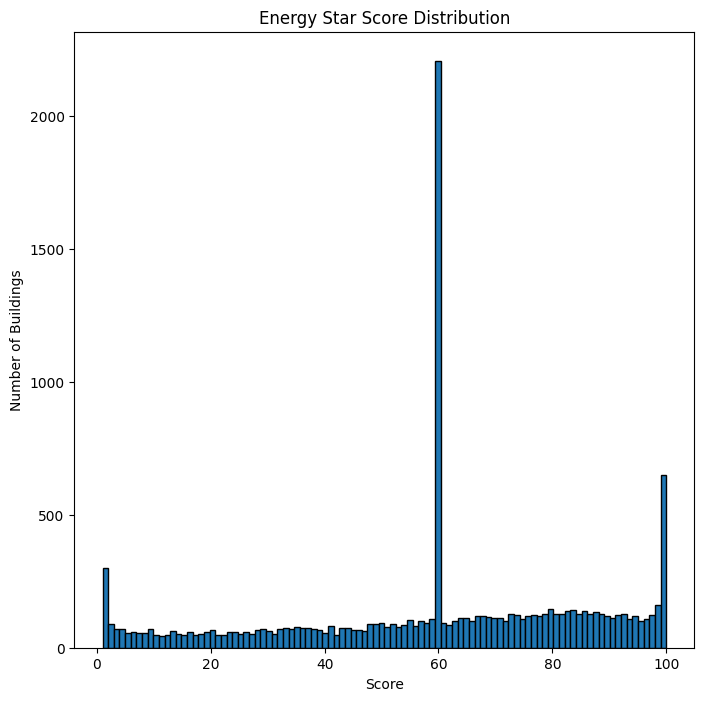

In [32]:
figsize(8, 8)

# For convenience, let's rename the 'ENERGY STAR Score' column to 'score' using the rename method
data = data.rename(columns = {'ENERGY STAR Score': 'score'})

# Let's build a histogram of the distribution of the score column using the plt.hist function, specifying the number of bins (for example, 100)
plt.hist(data['score'], bins = 100, edgecolor = 'k')

plt.xlabel('Score')
plt.ylabel('Number of Buildings')
plt.title('Energy Star Score Distribution')
#plt.style.use('fivethirtyeight')

#### Question

Why is the distribution this way? What can you say? What conclusions arise?

#### Conclusion

**Looks pretty suspicious so far!**

The rating we are interested in is a percentile, so we would expect to see a uniform distribution, with approximately the same number of buildings corresponding to each value. Although in our case there is a disproportion, most buildings have a maximum rating value of 100 or a minimum rating of 1 (a high rating is a good indicator).

Let's look at the description of the feature and remember that it is based on “provided energy consumption reports.” This might explain something. Asking building owners to report on energy efficiency is almost like asking a student to grade themselves on an exam. As a result, we do not get the most objective assessment of the efficiency of energy use in buildings.

If time were not limited, it would be worthwhile to find out why most buildings have ratings that are too high or too low. To do this, you need to filter the records by these buildings and see what they have in common. It's not our goal to invent a new method for assessing energy efficiency, so it's best to focus on rating prediction with what we have for now.

In [ ]:
data[data['score'] <= 1].head(2)

### Analysis of non-target variables

Now let's do the research for other variables (non-target).

Let's build a histogram of the distribution of the Site EUI field using the `plt.hist` function, specifying the number of bins (for example, 200)


In [ ]:
figsize(6, 6)

plt.hist(data['Site EUI (kBtu/ft²)'], bins = 200, edgecolor = 'black')

plt.xlabel('Site EUI')
plt.ylabel('Count')
plt.title('Site EUI Distribution')

What can you see in this histogram? What is actually happening on the graph?

Here, in this graph, we see obvious outliers! Because of this, the poor histogram was flattened so much...

Let's look at the statistics of this column using the `describe()` method

In [ ]:
data['Site EUI (kBtu/ft²)'].describe()

Just look at the spread between the third quartile and the maximum...

Let's look at the top 10 largest values ​​in this column:

In [ ]:
data['Site EUI (kBtu/ft²)'].dropna().sort_values().tail(10)

Let's look at how many objects there are with a metric value greater than 1000:

In [ ]:
data[data['Site EUI (kBtu/ft²)'] > 1000].shape[0]

There are only 47 of them!

Let's take a closer look at these emissions:

In [ ]:
data.loc[data['Site EUI (kBtu/ft²)'] > 1000, :]

Are there any patterns in the data? Can any conclusions be drawn regarding these buildings?

Let's use boxplot from the seaborn library to make sure that these objects really look like outliers

In [ ]:
plt.figure(figsize=(5, 4))

sns.boxplot(data=data['Site EUI (kBtu/ft²)'])

What went wrong again?...

---

### Reminder: BoxPlot

<img src=https://i.ytimg.com/vi/BE8CVGJuftI/maxresdefault.jpg width="700">

Box plot is a graph used in descriptive statistics that compactly depicts a one-dimensional probability distribution.

This type of chart shows in a convenient form the median (or, if necessary, the mean), lower and upper quartiles, minimum and maximum sample values, and outliers.

Several of these boxes can be drawn side by side to visually compare one distribution to another; they can be placed both horizontally and vertically. The distances between different parts of the box allow you to determine the degree of spread (dispersion) and asymmetry of the data and identify outliers.

---



### Working with outliers

In order to perform Univariate analysis efficiently, we need to learn how to get rid of outliers after they have been identified.

In general, [outliers](https://www.itl.nist.gov/div898/handbook/prc/section1/prc16.htm) can be due to various reasons: typos, errors in units of measurement, or even correct, but too big values.

You can remove outliers in different ways, but one of the most popular is the following one:

- Below the first quartile - `3 iqr` (interquartile distance)
- Above third quartile + `3 iqr` (interquartile distance)

Moreover, `3` is not some kind of constant and may well vary from task to task.


In [ ]:
# Calculate the first and third quartiles of the Site EUI field or take the values ​​from the output of the describe method
first_quartile = data['Site EUI (kBtu/ft²)'].describe()['25%']
third_quartile = data['Site EUI (kBtu/ft²)'].describe()['75%']

# Let's calculate IQR as the difference between the third and first quartiles
iqr = third_quartile - first_quartile

Let's create a condition on the Site EUI column to select NOT emissions using the expression above

In [ ]:
condition = (data['Site EUI (kBtu/ft²)'] > (first_quartile - 3 * iqr)) & (data['Site EUI (kBtu/ft²)'] < (third_quartile + 3 * iqr))
condition

Let's apply the created condition to our data, filtering out rows that are not outliers

In [ ]:
data = data[condition]

In [ ]:
# Let's see what has happened to our dataset's size
data.shape

In [ ]:
# Let's look at the data itself to make sure everything is in order
data.head()

Looks good! Let's now build a histogram of the distribution of the Site EUI field again using the `plt.hist` function, specifying the number of bins (for example, 20). Let's check how much our outlier removal measures actually helped!


In [ ]:
figsize(6, 6)

plt.hist(data['Site EUI (kBtu/ft²)'], bins = 20, edgecolor = 'black')

plt.xlabel('Site EUI')
plt.ylabel('Count')
plt.title('Site EUI Distribution')

Amazing! It even closely resembles a normal distribution, which is great for our data!

Let's now use the boxplot from the seaborn library again to make sure that the outliers have disappeared and that we did everything correctly!

In [ ]:
plt.figure(figsize=(8, 7))

sns.boxplot(data=data['Site EUI (kBtu/ft²)'].values, color = 'aquamarine')

Really amazing work! Well done! :)

#### Question

Why, if the work is so good, box-plot still detects some outliers in the graph?

### Other ways to control outliers

In addition to the method we used, there are the following ways to deal with outliers:


- **Dropping the outlier rows with standard deviation**
```
factor = 3
upper_lim = data['column'].mean() + data['column'].std() * factor
lower_lim = data['column'].mean() - data['column'].std() * factor
data = data[(data['column'] < upper_lim) & (data['column'] > lower_lim)]
```

- **Dropping the outlier rows with Percentiles**
```
upper_lim = data['column'].quantile(.95)
lower_lim = data['column'].quantile(.05)
data = data[(data['column'] < upper_lim) & (data['column'] > lower_lim)]
```

**Examples of other methods:**

- Winsorization is a series of transformations aimed at limiting the impact of outliers. 90% winsorization means that we take values ​​less than the 5% percentile and above the 95% percentile and equate them to the values ​​at the 5th and 95th percentiles.
- Trimming differs from winsorization in that we do not limit the extreme values ​​to any number, but simply remove them.

You can find more methods on [scipy.stats.mstats](https://docs.scipy.org/doc/scipy-0.14.0/reference/stats.mstats.html)

Well, let's go back to the analysis :)


## Multivariate analysis

A significant part of the work at the EDA stage is the search for connections between various features. Obviously, the feautures and values ​​of the features that have the main influence on the target, interest us more than others - it is best to use them to predict the value of the target.


### Impact of a categorical variable on a target variable

One way to assess the influence of categorical feature values ​​(the number of values ​​of such a feature is assumed to be final) on the target feature is to construct a density plot, for example, using the seaborn module. Density plot can be imagined of as a smoothed histogram or a density function for some distribution.

When this visualization is applied in conjunction with a target variable and a non-target categorical variable, we obtain the distribution of the target feature for one specific category.

The code below builds a density plot to rank energy consumption based on building type. Ratings for different types are shown in different colors (only building types with at least a hundred records in our data set are taken into consideration):

In [ ]:
# Let's create a list of types with the names of categories of buildings with more than 100 dimensions
types = data.dropna(subset=['score'])
types = types['Largest Property Use Type'].value_counts()
types = list(types[types.values > 100].index)
types.remove('Other')

In [ ]:
figsize(10, 6)

# Plot the distribution of ratings for each type of building from the types list on one graph
for b_type in types:
    # Select data from one of the building types from the types list
    subset = data[data['Largest Property Use Type'] == b_type]

    # Use seaborn's kdeplot function to plot the distribution
    sns.kdeplot(subset['score'], label = b_type, fill = False, alpha = 0.8)

plt.xlabel('Energy Star Score', size = 18)
plt.ylabel('Density', size = 18)
plt.title('Density Plot of Energy Star Scores by Building Type', size = 22)
plt.legend(fontsize=14)

What results are you seeing? What conclusions can be drawn from the graph?

It can be seen that the building type has a significant impact on the energy rating. Buildings used as offices are more likely to have a good rating, while hotels are the opposite. It turns out that such a feature as the type of building is important for us. Since this is a categorical feature, we still have to perform the so-called “one-hot encoding” with it. But that's later.

Let's now repeat similar steps for different areas:

In [ ]:
# Let's create a list of boroughs with the names of boroughs with more than 100 dimensions
boroughs = data.dropna(subset=['score'])
boroughs = boroughs['Borough'].value_counts()
boroughs = list(boroughs[boroughs.values > 100].index)

In [ ]:
figsize(9, 6)

# Plot the distribution of scores for each borough from the list of boroughs on one graph
for borough in boroughs:
    # Select the details of one of the borough from the list of boroughs
    subset = data[data['Borough'] == borough]

    # Use seaborn's kdeplot function to plot the distribution
    sns.kdeplot(subset['score'], label = borough)

plt.xlabel('Energy Star Score', size = 18)
plt.ylabel('Density', size = 18)
plt.title('Density Plot of Energy Star Scores by Borough', size = 22)
plt.legend(fontsize=14)

What conclusions can be drawn here?

The area doesn't seem to have as much influence anymore. Nevertheless, it is perhaps worth including this feature in the model, since there is still a certain difference between the regions.

### Correlations between feautures and target variable

To numerically assess the degree of influence of features, you can use the [Pearson correlation coefficient](http://www.statisticshowto.com/probability-and-statistics/correlation-coefficient-formula/).

It is a measure of the strength and positivity of linear connections between two variables. A value of +1 means ideal proportionality between the values ​​of the characteristics and, accordingly, a value of -1 is similar, but with a negative coefficient.

Although this doesn't give us any idea of ​​disproportionate connections, it's a good start. In Pandas, calculating the magnitude of the correlation is quite easy:

```
correlations_data = data.corr()['score'].sort_values()
```

In [ ]:
# Let's use the corr() method, select the column with the target label 'score' and sort the correlation values
correlations_data = data.corr()['score'].sort_values()

# We will display 15 features with the lowest direct correlation
print(correlations_data.head(15))

print('------------')

# We will display 15 features with the highest direct correlation
print(correlations_data.tail(15))

As you can see, there are several features in the data that have high negative Pearson correlation coefficient values.

The largest (in absolute value) correlation is achieved for different EUI categories (they differ slightly in the calculation method). EUI — Energy Use Intensity — is the amount of energy used divided by the square footage of the premises. This means that the lower this feature, the better. Accordingly: as EUI increases, the energy consumption rating, on the contrary, becomes lower.

Already some good conclusions for us within the EDA!

Let's use the heatmap function of the seaborn library to draw the entire correlation matrix (heat map)

In [ ]:
sns.set(font_scale=1.4)
plt.figure(figsize=(15,15))

sns.heatmap(data.corr(), cbar=True, cmap='coolwarm')

What conclusions can be drawn based on such a heat map?

### Bivariate analysis

To perform bivariate analysis, or otherwise, analyze the connection between two continuous variables, you can use a scatterplot (scatterplot or scatter plots). Additional information, such as categorical feature values, can be shown in different colors.

For example, the graph below shows us the spread of energy rating depending on the Site EUI value, and the types of buildings (taken from the previous paragraphs) are shown in different colors:

In [ ]:
# Let's make a copy of our dataset, in case not to worsen anything
features = data.copy()

In [ ]:
figsize(8, 6)

# Let's select only those rows that correspond to building types containing more than 100 records (.isin(types))
features = features[features['Largest Property Use Type'].isin(types)]

# Let's use the lmplot function of the seaborn library to plot a scatterplot graph
# Along the axes of which there will be the score and Site EUI columns, and the points are divided into groups by building type
sns.lmplot(x = 'Site EUI (kBtu/ft²)', y = 'score',
          hue = 'Largest Property Use Type', data = features,
          scatter_kws = {'alpha': 0.8, 's': 60}, fit_reg = False, aspect = 1.2)

plt.xlabel('Site EUI', size = 18)
plt.ylabel('Energy Star Score', size = 18)
plt.title('Energy Star Score vs Site EUI', size = 22);

This graph clearly demonstrates what a correlation coefficient with a value of -0.7 is: Site EUI decreases and the energy rating confidently increases, regardless of the type of building.

### Pairs plot

And finally, let's build a Pairs Plot. Pairs Plot is a powerful research tool that allows you to look at the connections between several features at once, as well as their joint pairwise distributions.

In the example below, the seaborn module and the PairGrid function were used during construction. Pairs Plot was built with scatterplots above the main diagonal, histograms on the main diagonal and 2D kernel density plots, indicating the correlation, below the main diagonal.

In [ ]:
# Let's select the columns that we will look at in pairs
plot_data = features[['score', 'Site EUI (kBtu/ft²)',
                      'Weather Normalized Source EUI (kBtu/ft²)']]

# Replace infinity with np.nan using the replace function
plot_data = plot_data.replace({np.inf: np.nan, -np.inf: np.nan})

# For convenience, let's rename the columns
plot_data = plot_data.rename(columns = {'Site EUI (kBtu/ft²)': 'Site EUI',
                                        'Weather Normalized Source EUI (kBtu/ft²)': 'Weather Norm EUI',
                                        'log_Total GHG Emissions (Metric Tons CO2e)': 'log GHG Emissions'})

# Remove missing values
plot_data = plot_data.dropna()

# Let's use the following function to calculate the correlation between two vectors
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size = 20)

# Let's create a PairGrid object and configure the display of graphs in it
grid = sns.PairGrid(data = plot_data)

# If you are interested in what each method is responsible for, then you can poke them and see how the result changes :)
grid.map_upper(plt.scatter, color = 'red', alpha = 0.6)
grid.map_diag(plt.hist, color = 'red', edgecolor = 'black')
grid.map_lower(corr_func);
grid.map_lower(sns.kdeplot, cmap = plt.cm.Reds)

plt.suptitle('Pairs Plot of Energy Data', size = 28, y = 1.02);

In order to look at the connections between quantities that interest us, it is enough to simply take the intersection of the required row and column. For example, to look at the correlation between Weather Norm EUI and score, look at the Weather Norm EUI row and score column, respectively. It can also be seen that, for example, the Pearson correlation coefficient between them is -0.26.



Besides the fact that the graph looks pretty nice, it can also help us understand what features should be included in our model.